<a href="https://colab.research.google.com/github/BannoTaichi/BallCrastering/blob/main/ballCrastering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ボールの分類AI**

## **ImageNetを用いた学習済みモデルの転移学習**

### iCrawlerによる画像スクレイピング

In [2]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
%cd "/content/drive/MyDrive/ballCrastering"

/content/drive/MyDrive/ballCrastering


In [4]:
%mkdir "/content/drive/MyDrive/ballCrastering/images"

mkdir: cannot create directory ‘/content/drive/MyDrive/ballCrastering/images’: File exists


In [5]:
!pip install icrawler

In [6]:
from icrawler.builtin import BingImageCrawler
import os

test_path = "/content/drive/MyDrive/ballCrastering/test"
train_path = "/content/drive/MyDrive/ballCrastering/train"
labels = ["バスケボール", "テニスボール", "ゴルフボール"]
# for label in labels:
#     path = train_path + "/" + label
#     trainCrawler = BingImageCrawler(storage={"root_dir": path})
#     trainCrawler.crawl(keyword=label, max_num=180)
#     path = test_path + "/" + label
#     testCrawler = BingImageCrawler(storage={"root_dir": path})
#     testCrawler.crawl(keyword=label, max_num=20)

### モデルの構築

In [7]:
!pip install keras

In [8]:
from gc import callbacks
import tensorflow
from tensorflow.keras.layers import Input,Dense,Flatten,Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import optimizers
from tensorflow.keras.applications.resnet50 import ResNet50,preprocess_input
from tensorflow.keras import Model
from tensorflow.keras.preprocessing import image
from tensorflow.keras.callbacks import EarlyStopping
import numpy as np
from PIL import Image
import os

labels = ["バスケボール", "テニスボール", "ゴルフボール"]
label_num = len(labels)

os.environ['KMP_DUPLICATE_LIB_OK']='True'

ResNet_model = ResNet50(weights='imagenet',include_top=False, input_tensor=Input(shape=(224,224,3)))

# 既存のResNetモデルの出力部分をinputという変数に代入
inputs = ResNet_model.output

x = Flatten()(inputs)

x = Dense(2048, kernel_regularizer=tensorflow.keras.regularizers.l2(0.001),activation='relu')(x)

x = Dropout(0.25)(x)

x = Dense(1024,activation='relu')(x)

x = Dropout(0.25)(x)

prediction = Dense(label_num,activation='softmax')(x)

model=Model(inputs=ResNet_model.input,outputs=prediction)

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


### 学習の設定
- データのかさ増し
- コンパイル
- 過学習の防止

In [9]:
model.compile(
    optimizer=optimizers.RMSprop(
              learning_rate=0.0001,
              rho=0.9,
              momentum=0.0,
              epsilon=1e-7,
              centered=False),
    loss='categorical_crossentropy',
    metrics=['accuracy'])

gen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    width_shift_range=0.2,
    height_shift_range=0.2,
    rotation_range=20,
    horizontal_flip=True,
    fill_mode='constant',
    cval=0,
    validation_split = 0.1)

train_gen = gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    class_mode='categorical',
    shuffle=True,
    subset = "training")

val_gen = gen.flow_from_directory(
    train_path,
    target_size=(224,224),
    class_mode='categorical',
    shuffle=True,
    subset = "validation")

early_stopping =  EarlyStopping(
    monitor='val_loss',
    min_delta=0.0,
    patience=5)

Found 147 images belonging to 3 classes.
Found 15 images belonging to 3 classes.


### モデルの学習

Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


 5/32 ━━━━━━━━━━━━━━━━━━━━ 3:23 8s/step - accuracy: 0.3330 - loss: 16.5467 

/usr/lib/python3.10/contextlib.py:153: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


32/32 ━━━━━━━━━━━━━━━━━━━━ 145s 1s/step - accuracy: 0.3849 - loss: 22.1206 - val_accuracy: 0.7333 - val_loss: 7.2972
Epoch 2/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.6502 - loss: 6.9906 - val_accuracy: 0.7333 - val_loss: 6.2989
Epoch 3/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 50ms/step - accuracy: 0.8874 - loss: 4.7162 - val_accuracy: 1.0000 - val_loss: 4.0231
Epoch 4/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 51ms/step - accuracy: 0.9422 - loss: 4.1781 - val_accuracy: 0.9333 - val_loss: 4.2248
Epoch 5/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 5s 51ms/step - accuracy: 0.9549 - loss: 4.1172 - val_accuracy: 0.9333 - val_loss: 4.0774
Epoch 6/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 78ms/step - accuracy: 0.9716 - loss: 4.1225 - val_accuracy: 0.8667 - val_loss: 5.6912
Epoch 7/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 9s 51ms/step - accuracy: 0.9635 - loss: 4.0639 - val_accuracy: 0.9333 - val_loss: 4.6133
Epoch 8/30
32/32 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - accuracy: 1.0000 - loss: 3.9703 - val_accuracy: 0.9333 - val_loss: 4

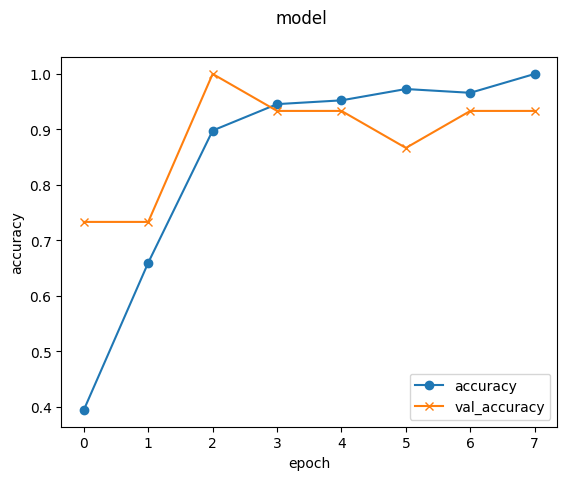

In [10]:
import matplotlib.pyplot as plt

history = model.fit(
        train_gen,
        steps_per_epoch=32,
        epochs=30,
        verbose=1,
        validation_data=val_gen,
        callbacks=[early_stopping]
)

plt.plot(history.history['accuracy'], label='accuracy', ls='-', marker='o')
plt.plot(history.history['val_accuracy'], label='val_accuracy', ls='-', marker='x')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.suptitle('model', fontsize=12)
plt.legend()
plt.show()

In [11]:
model.save("ballCrasteringModel.h5")

### テストデータの精度評価

In [12]:
from tensorflow.keras.models import load_model

classes = os.listdir("/content/drive/MyDrive/ballCrastering/train")  # 指定したフォルダの中に入っているファイルまたはフォルダの名前をリストにして返してくれる関数（正解ラベルをリストにしてまとめている）
model = load_model("ballCrasteringModel.h5")
# 作成したモデルのロードをして変数に代入


def predict(input_filename):

    input = image.load_img(input_filename, target_size=(224, 224))

    input = np.expand_dims(input, axis=0)

    input = preprocess_input(input)

    result = model.predict(input)

    label = classes[np.argmax(result[0])]  # 最も値の大きい要素番号を取得
    probability = result[0][np.argmax(result[0])] * 100

    return label, probability


# テストデータのうち、何枚正解ラベルと予測した値が一致したのかを確認するコード
if __name__ == "__main__":
    test_filename = "/content/drive/MyDrive/ballCrastering/test"
    test_classes = os.listdir(test_filename)  # サブディレクトリのフォルダ名をリストとして取得
    count = 0  # テストするすべてのファイルの数
    acc_count = 0  # 正解数
    for test_class in test_classes:  # jでファイルのパスを取得し、predictの引数に入力
        for name in os.listdir(test_filename + "/" + test_class):
            count += 1
            x, y = predict(test_filename + "/" + test_class + "/" + name)
            print(f"predict : {x}, {y}\ntest_class : {test_class}")
            if x == test_class:
              # print(test_class)
              acc_count += 1

    print(f"accuracy : {acc_count/count}\nacc_count : {acc_count}\ncount : {count}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
predict : ゴルフボール, 100.0
test_class : バスケボール
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step
predict : ゴルフボール, 100.0
test_class : バスケボール
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
predict : ゴルフボール, 100.0
test_class : バスケボール
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
predict : ゴルフボール, 100.0
test_class : バスケボール
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
predict : ゴルフボール, 100.0
test_class : バスケボール
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
predict : ゴルフボール, 100.0
test_class : バスケボール
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
predict : テニスボール, 100.0
test_class : テニスボール
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step
predict : テニスボール, 100.0
test_class : テニスボール
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
predict : テニスボール, 100.0
test_class : テニスボール
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
predict : テニスボール, 99.99990463256836
test_class : テニスボール
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
predict : テニスボール, 100.0
test_class : テニスボール
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
predict : テニスボー

### モデルの確認

In [13]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 224, 224, 3)    │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_pad (ZeroPadding2D) │ (None, 230, 230, 3)    │              0 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_conv (Conv2D)       │ (None, 112, 112, 64)   │          9,472 │ conv1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_bn                  │ (None, 112, 112, 64)   │            256 │ conv1_conv[0][0]       │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv1_relu (Activation)   │ (None, 112, 112, 64)   │              0 │ conv1_bn[0][0]         │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pad (ZeroPadding2D) │ (None, 114, 114, 64)   │              0 │ conv1_relu[0][0]       │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ pool1_pool (MaxPooling2D) │ (None, 56, 56, 64)     │              0 │ pool1_pad[0][0]        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_conv       │ (None, 56, 56, 64)     │          4,160 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_1_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_1_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_1_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_conv       │ (None, 56, 56, 64)     │         36,928 │ conv2_block1_1_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_bn         │ (None, 56, 56, 64)     │            256 │ conv2_block1_2_conv[0… │
│ (BatchNormalization)      │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_2_relu       │ (None, 56, 56, 64)     │              0 │ conv2_block1_2_bn[0][… │
│ (Activation)              │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_0_conv       │ (None, 56, 56, 256)    │         16,640 │ pool1_pool[0][0]       │
│ (Conv2D)                  │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2_block1_3_conv       │ (None, 56, 56, 256)    │         16,640 │ conv2_block1_2_relu[0… │
│ (Conv2D)                  │                        │                │                        │
├──────────────────────

 Total params: 231,211,909 (882.00 MB)

 Trainable params: 231,158,787 (881.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

 Optimizer params: 2 (12.00 B)